First 5 rows of dataset:
   student_id  age  gender             major  study_hours_per_day  \
0      100000   26    Male  Computer Science             7.645367   
1      100001   28    Male              Arts             5.700000   
2      100002   17    Male              Arts             2.400000   
3      100003   27   Other        Psychology             3.400000   
4      100004   25  Female          Business             4.700000   

   social_media_hours  netflix_hours part_time_job  attendance_percentage  \
0                 3.0            0.1           Yes                   70.3   
1                 0.5            0.4            No                   88.4   
2                 4.2            0.7            No                   82.1   
3                 4.6            2.3           Yes                   79.3   
4                 0.8            2.7           Yes                   62.9   

   sleep_hours  ... screen_time  study_environment access_to_tutoring  \
0          6.2  ...     

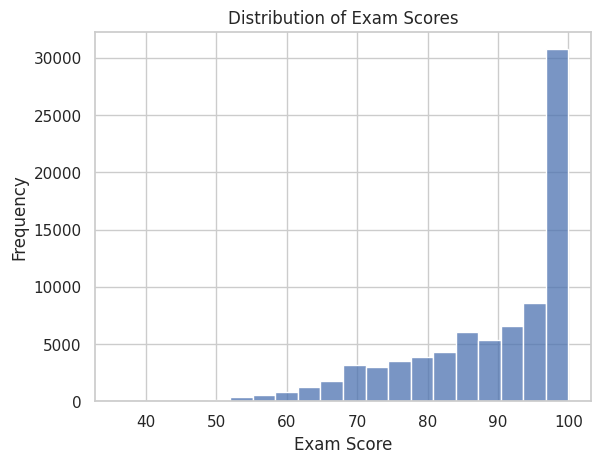

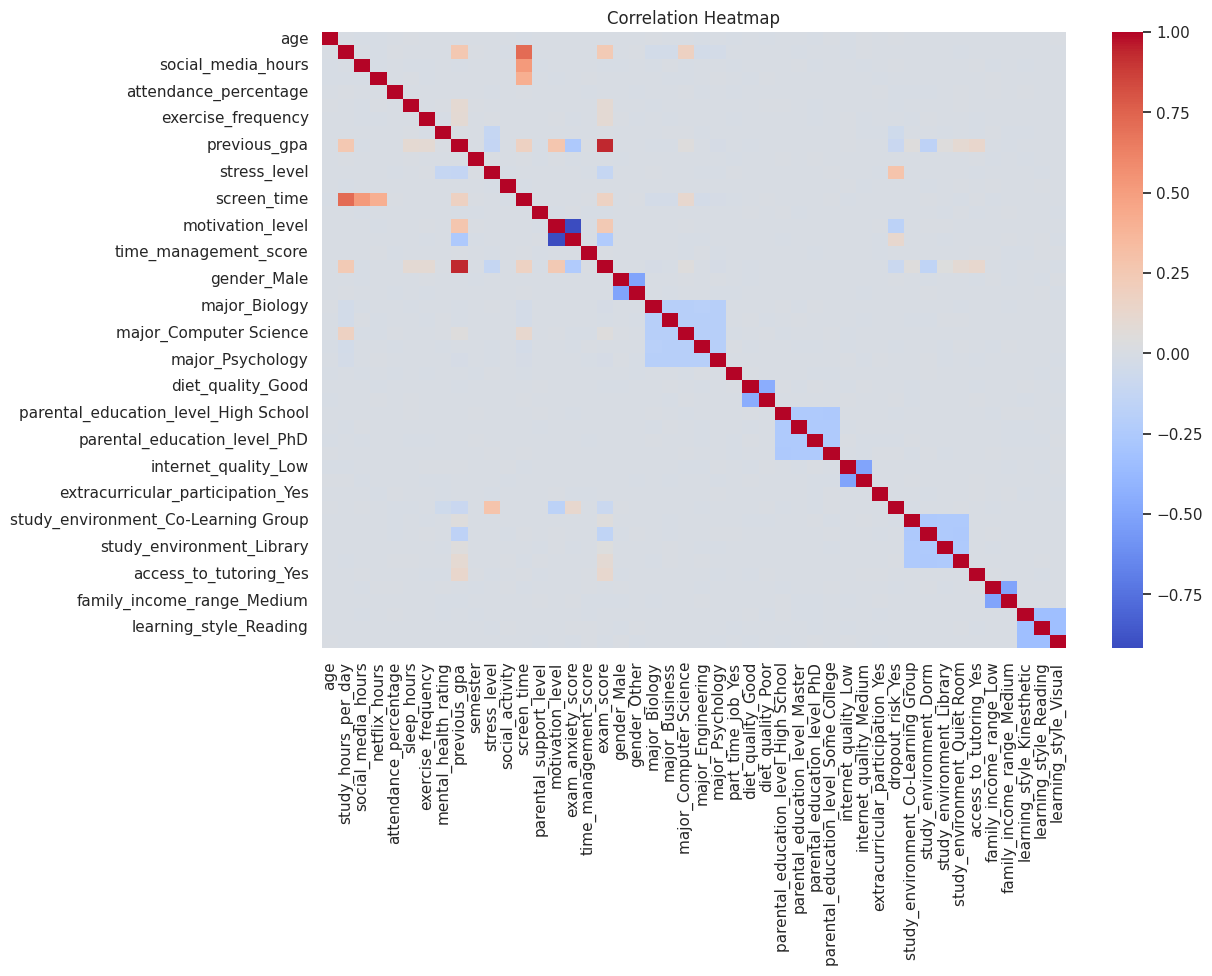

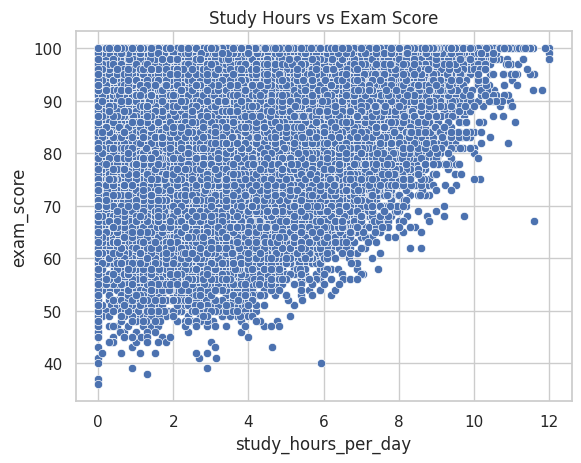

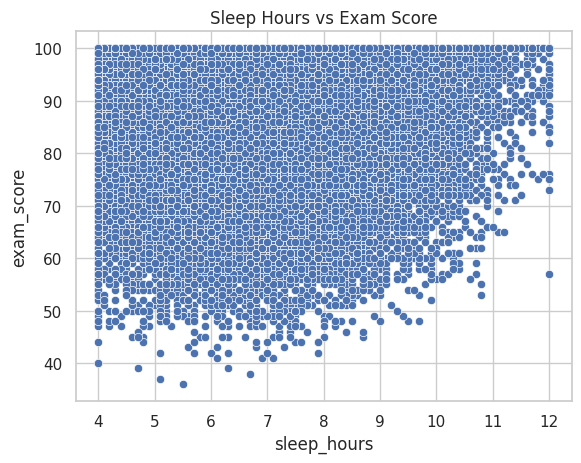


--- Regression Model Performance ---
R2 Score: 0.8703789533840951
Mean Squared Error: 17.549185499547793

--- Classification Model Performance ---
Accuracy: 0.9981875


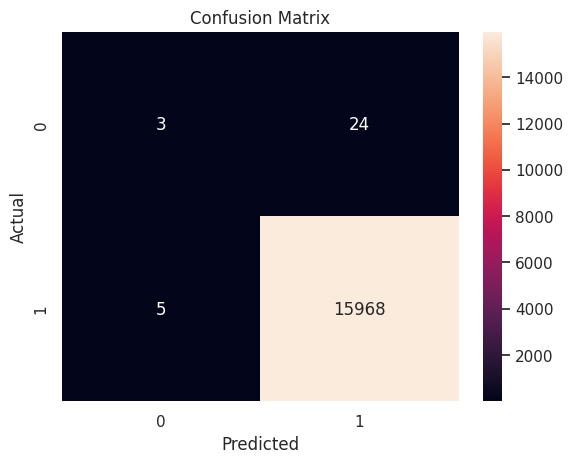


Top Influential Features:
                                 Feature  Coefficient
8                           previous_gpa    23.349414
27  parental_education_level_High School     0.086938
23                      major_Psychology     0.052406
43                learning_style_Reading     0.050233
3                          netflix_hours     0.048737
1                    study_hours_per_day     0.040297
2                     social_media_hours     0.036882
40               family_income_range_Low     0.032865
29          parental_education_level_PhD     0.030973
20                        major_Business     0.027900


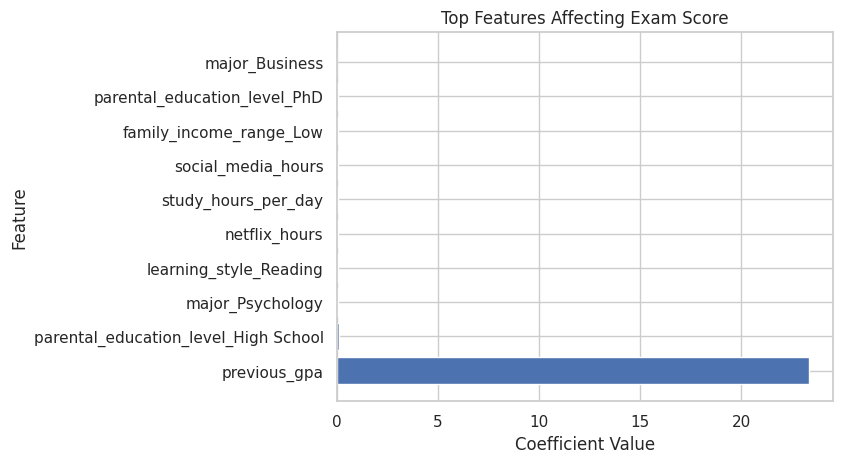

In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

# Set plot style
sns.set(style="whitegrid")

# ============================================================
# 2. LOAD DATASET
# ============================================================

# Load dataset (ensure file is uploaded in notebook)
df = pd.read_csv('enhanced_student_habits_performance_dataset.csv')

print("First 5 rows of dataset:")
print(df.head())

# ============================================================
# 3. DATA EXPLORATION
# ============================================================

print("\nDataset shape:", df.shape)

print("\nData Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

# ============================================================
# 4. DATA CLEANING & PREPROCESSING
# ============================================================

# Check missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Handle missing values using mean imputation
df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Drop irrelevant column
if 'student_id' in df.columns:
    df = df.drop('student_id', axis=1)
    print("\nDropped 'student_id' column.")

# Convert categorical variables into numerical (One-Hot Encoding)
df = pd.get_dummies(df, drop_first=True)

print("\nData after encoding:")
print(df.head())

# ============================================================
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# 5.1 Distribution of Exam Scores
plt.figure()
sns.histplot(df['exam_score'], bins=20)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.savefig("distribution_exam_scores.png", dpi=300, bbox_inches='tight')
plt.show()

# 5.2 Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# 5.3 Study Hours vs Exam Score
if 'study_hours_per_day' in df.columns:
    plt.figure()
    sns.scatterplot(x=df['study_hours_per_day'], y=df['exam_score'])
    plt.title("Study Hours vs Exam Score")
    plt.savefig("study_vs_score.png", dpi=300, bbox_inches='tight')
    plt.show()

# 5.4 Sleep Hours vs Exam Score
if 'sleep_hours' in df.columns:
    plt.figure()
    sns.scatterplot(x=df['sleep_hours'], y=df['exam_score'])
    plt.title("Sleep Hours vs Exam Score")
    plt.savefig("sleep_vs_score.png", dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================
# 6. FEATURE SELECTION
# ============================================================

# Define features and target
X = df.drop('exam_score', axis=1)
y = df['exam_score']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================
# 7. FEATURE SCALING (IMPORTANT STEP)
# ============================================================

# Scale features for better model performance
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# 8. LINEAR REGRESSION MODEL
# ============================================================

# Create model
reg_model = LinearRegression()

# Train model
reg_model.fit(X_train, y_train)

# Predictions
y_pred = reg_model.predict(X_test)

# Evaluation
print("\n--- Linear Regression Performance ---")
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# ============================================================
# 9. CROSS VALIDATION (MODEL VALIDATION)
# ============================================================

# Perform 5-fold cross-validation
cv_scores = cross_val_score(reg_model, X, y, cv=5, scoring='r2')

print("\n--- Cross Validation ---")
print("CV R2 Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

# ============================================================
# 10. RANDOM FOREST (EXTRA MODEL FOR ORIGINALITY)
# ============================================================

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
print("\n--- Random Forest Performance ---")
print("R2 Score:", r2_score(y_test, rf_pred))
print("Mean Squared Error:", mean_squared_error(y_test, rf_pred))

# ============================================================
# 11. CLASSIFICATION (PASS / FAIL)
# ============================================================

# Create pass/fail column
df['pass'] = df['exam_score'].apply(lambda x: 1 if x >= 50 else 0)

# Features and target
X_class = df.drop(['exam_score', 'pass'], axis=1)
y_class = df['pass']

# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Scale classification data
X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

# Logistic Regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_c, y_train_c)

# Predictions
y_pred_c = clf.predict(X_test_c)

# Evaluation
print("\n--- Classification Model Performance ---")
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 12. FEATURE IMPORTANCE (INTERPRETATION)
# ============================================================

# Get coefficients (Linear Regression)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': reg_model.coef_
})

# Sort features
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print("\nTop Influential Features:")
print(coefficients.head(10))

# Plot top features
top_features = coefficients.head(10)

plt.figure()
plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.title("Top Features Affecting Exam Score")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()